In [1]:
import datetime
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from plotly.colors import n_colors
import plotly.graph_objects as go
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
def millions(x, pos):
    'The two args are the value and tick position'
    return '%1.1fM' % (x * 1e-6)
def billions(x, pos):
    'The two args are the value and tick position'
    return '%1.1fB' % (x * 1e-9)

In [4]:
formatter = FuncFormatter(millions)
formatter2 = FuncFormatter(billions)

In [5]:
io_cashflow = '2026 Q1 NLIC FHLB CLO Balance Forecast.xlsx'
tranches = pd.read_excel(io_cashflow,sheet_name='Scenario 8',nrows=1)
tranches = tranches.dropna(axis='columns').transpose()
tranches.columns = ['cusip']
tranches[tranches.cusip == 'XXXXXXXXX'].cusip = tranches[tranches.cusip == 'XXXXXXXXX'].index

names = []
for i in tranches.index:
    if i in tranches[tranches.cusip == 'XXXXXXXXX'].index:
        names.append(i)
    else:
        names.append(tranches.loc[i].cusip)
names = names[1:]
df_list = []
for i in np.arange(8):
    sheet_name_scenario = f'Scenario {i+1}'
    cashflow = pd.read_excel(io_cashflow,sheet_name=sheet_name_scenario,header=2)
    cashflow.fillna(0.0,inplace=True)
    cashflow.rename( columns={'Unnamed: 0':'Date'}, inplace=True )
    df_list.append(cashflow)

In [6]:
col_names = []
sheetname = 'Summary'
max = 0
for d in np.arange(len(df_list)):
    if len(df_list[d]) > max:
        max = len(df_list[d])
        scen = d+1
index_values = df_list[scen-1].Date.values
for s in np.arange(len(df_list)):
    col_names.append(f'Scenario {s+1}')

    working = df_list[s]
    
    interest_cols = [col for col in working.columns if 'Interest' in col]
    principal_cols = [col for col in working.columns if 'Principal' in col]
    balance_cols = [col for col in working.columns if 'Balance' in col]
    
    working_interest = working[working.columns[working.columns.isin(interest_cols)]]
    working_interest.drop(columns=working_interest.columns[0], axis=1,  inplace=True)
    working_interest.columns = names
    
    working_principal = working[working.columns[working.columns.isin(principal_cols)]]
    working_principal.drop(columns=working_principal.columns[0], axis=1,  inplace=True)
    working_principal.columns = names
    
    working_balance = working[working.columns[working.columns.isin(balance_cols)]]
    working_balance.drop(columns=working_balance.columns[0], axis=1,  inplace=True)
    working_balance.columns = names

    b = working_balance.sort_index(axis=1).values
    b_ = np.expand_dims(np.sum(b,axis=1),axis=1)

    i = working_interest.sort_index(axis=1).values
    i_ = np.expand_dims(np.sum(i,axis=1),axis=1)

    p = working_principal.sort_index(axis=1).values
    p_ = np.expand_dims(np.sum(p,axis=1),axis=1)

    while len(b_) < max:
        b_ = np.append(b_, np.expand_dims(b_[-1],axis=1).T , 0)
        i_ = np.append(i_, np.expand_dims(i_[-1],axis=1).T , 0)
        p_ = np.append(p_, np.expand_dims(p_[-1],axis=1).T , 0)

    if s==0:
        balance = b_
        interest = i_
        principal = p_
    else:
        balance = np.append(balance, b_,axis=1)
        interest = np.append(interest, i_,axis=1)
        principal = np.append(principal, p_,axis=1)

balance_df = pd.DataFrame(data = balance, index = index_values, columns = ['75 Tight','50 Tight','25 Tight','10 Tight','Flat','10 Wide','25 Wide','50 Wide'])
#balance_df.to_excel(outfile,sheet_name = 'Summary')

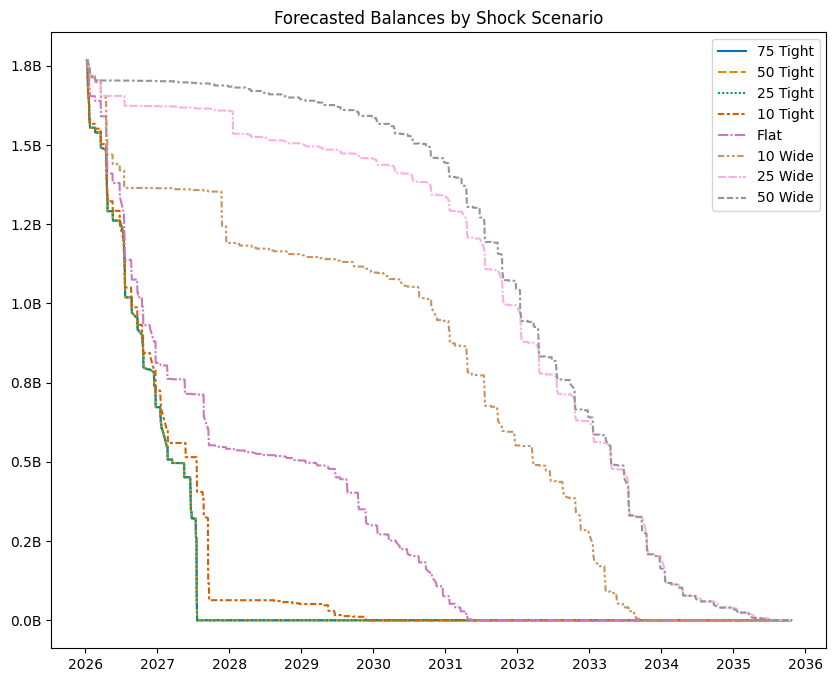

In [7]:
fig, ax = plt.subplots(figsize = (10,8))
sns.lineplot(data=balance_df,palette='colorblind')
ax.yaxis.set_major_formatter(formatter2)
plt.title('Forecasted Balances by Shock Scenario')
plt.show()

In [8]:
working = df_list[5]

interest_cols = [col for col in working.columns if 'Interest' in col]
principal_cols = [col for col in working.columns if 'Principal' in col]
balance_cols = [col for col in working.columns if 'Balance' in col]

working_interest = working[working.columns[working.columns.isin(interest_cols)]]
working_interest.drop(columns=working_interest.columns[0], axis=1,  inplace=True)
working_interest.columns = names

working_principal = working[working.columns[working.columns.isin(principal_cols)]]
working_principal.drop(columns=working_principal.columns[0], axis=1,  inplace=True)
working_principal.columns = names

working_balance = working[working.columns[working.columns.isin(balance_cols)]]
working_balance.drop(columns=working_balance.columns[0], axis=1,  inplace=True)
working_balance.columns = names

working_balance.index = working.Date
df = working_balance.reset_index()

df['Qdate'] = [date - pd.tseries.offsets.DateOffset(days=1) + pd.tseries.offsets.QuarterEnd() for date in  df.Date]
q = df['Qdate'].unique()

qe_dts = []
for i in q:
    temp = df[df.Date < i]
    qe_dts.append(temp.Date.values[-1])

QE =  df[df.Date.isin(qe_dts)]
QE.Date = QE['Qdate']
QE = QE.drop(columns=['Qdate'])


working_interest.index = working.Date
df2 = working_interest.reset_index()

PaymentDate1 = []
PaymentDate2 = []
Balance1 = []
Balance2 = []
for n in names:
    PaymentDate1.append(str(pd.to_datetime(df2.loc[df2[n].ne(0), 'Date'][0:2].values[0]).date()))
    Balance1.append(df.loc[df2[n].ne(0), n][0:2].values[0])
    if len(df2.loc[df2[n].ne(0), 'Date'].values) > 1:
        PaymentDate2.append(str(pd.to_datetime(df2.loc[df2[n].ne(0), 'Date'][0:2].values[1]).date()))
        Balance2.append(df.loc[df2[n].ne(0), n][0:2].values[1])
    else:
        PaymentDate2.append('NA')
        Balance2.append('NA')
    
    
data = list(zip(names, PaymentDate1, Balance1, PaymentDate2, Balance2))
hedging = pd.DataFrame(data, columns = ['cusips', 'Payment Date 1','Balance 1',  'Payment Date 2','Balance 2'])


In [9]:
outfile = '2026Q1_NLIC_CLO_FHLB_Balances_Flat.xlsx'
with pd.ExcelWriter(outfile) as writer:
   
    # use to_excel function and specify the sheet_name and index 
    # to store the dataframe in specified sheet
    #balance_df.to_excel(writer, sheet_name="Summary", index=False)
    QE.to_excel(writer, sheet_name="Quarterly Forecasting", index=False)
    hedging.to_excel(writer, sheet_name="Hedging", index=False)

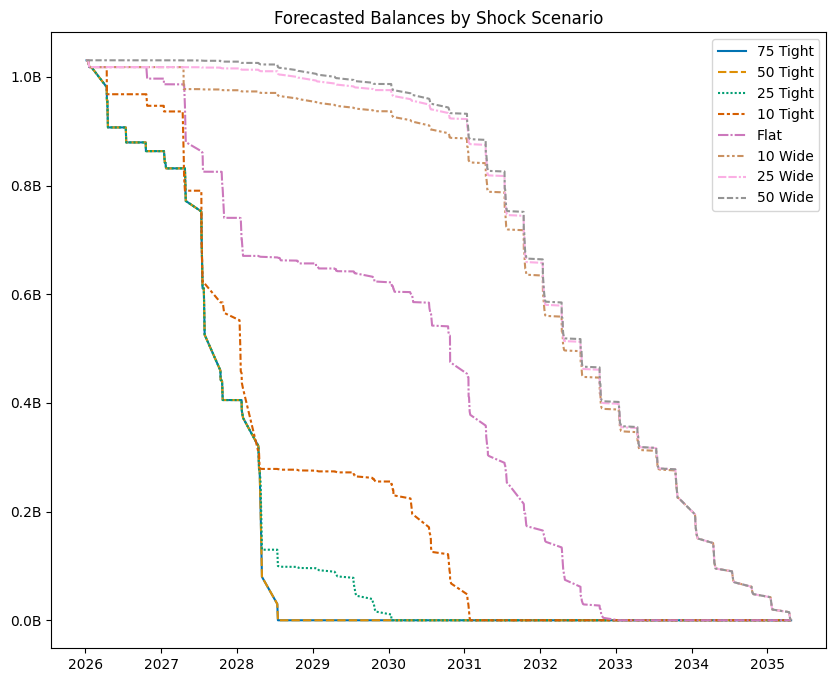

In [10]:
io_cashflow = '2026 Q1 NLAIC FHLB CLO Balance Forecast.xlsx'
outfile = '2026Q1_NLAIC_CLO_FHLB_Balances_Flat.xlsx'
tranches = pd.read_excel(io_cashflow,sheet_name='Scenario 8',nrows=1)
tranches = tranches.dropna(axis='columns').transpose()
tranches.columns = ['cusip']
tranches[tranches.cusip == 'XXXXXXXXX'].cusip = tranches[tranches.cusip == 'XXXXXXXXX'].index

names = []
for i in tranches.index:
    if i in tranches[tranches.cusip == 'XXXXXXXXX'].index:
        names.append(i)
    else:
        names.append(tranches.loc[i].cusip)
names = names[1:]
df_list = []
for i in np.arange(8):
    sheet_name_scenario = f'Scenario {i+1}'
    cashflow = pd.read_excel(io_cashflow,sheet_name=sheet_name_scenario,header=2)
    cashflow.fillna(0.0,inplace=True)
    cashflow.rename( columns={'Unnamed: 0':'Date'}, inplace=True )
    df_list.append(cashflow)

col_names = []
sheetname = 'Summary'
max = 0
for d in np.arange(len(df_list)):
    if len(df_list[d]) > max:
        max = len(df_list[d])
        scen = d+1
index_values = df_list[scen-1].Date.values
for s in np.arange(len(df_list)):
    col_names.append(f'Scenario {s+1}')
    
    working = df_list[s]
    
    interest_cols = [col for col in working.columns if 'Interest' in col]
    principal_cols = [col for col in working.columns if 'Principal' in col]
    balance_cols = [col for col in working.columns if 'Balance' in col]
    
    working_interest = working[working.columns[working.columns.isin(interest_cols)]]
    working_interest.drop(columns=working_interest.columns[0], axis=1,  inplace=True)
    working_interest.columns = names
    
    working_principal = working[working.columns[working.columns.isin(principal_cols)]]
    working_principal.drop(columns=working_principal.columns[0], axis=1,  inplace=True)
    working_principal.columns = names
    
    working_balance = working[working.columns[working.columns.isin(balance_cols)]]
    working_balance.drop(columns=working_balance.columns[0], axis=1,  inplace=True)
    working_balance.columns = names

    b = working_balance.sort_index(axis=1).values
    b_ = np.expand_dims(np.sum(b,axis=1),axis=1)

    i = working_interest.sort_index(axis=1).values
    i_ = np.expand_dims(np.sum(i,axis=1),axis=1)

    p = working_principal.sort_index(axis=1).values
    p_ = np.expand_dims(np.sum(p,axis=1),axis=1)

    while len(b_) < max:
        b_ = np.append(b_, np.expand_dims(b_[-1],axis=1).T , 0)
        i_ = np.append(i_, np.expand_dims(i_[-1],axis=1).T , 0)
        p_ = np.append(p_, np.expand_dims(p_[-1],axis=1).T , 0)

    if s==0:
        balance = b_
        interest = i_
        principal = p_
    else:
        balance = np.append(balance, b_,axis=1)
        interest = np.append(interest, i_,axis=1)
        principal = np.append(principal, p_,axis=1)

balance_df = pd.DataFrame(data = balance, index = index_values, columns = ['75 Tight','50 Tight','25 Tight','10 Tight','Flat','10 Wide','25 Wide','50 Wide'])
#balance_df.to_excel(outfile,sheet_name = 'Summary')

fig, ax = plt.subplots(figsize = (10,8))
sns.lineplot(data=balance_df,palette='colorblind')
ax.yaxis.set_major_formatter(formatter2)
plt.title('Forecasted Balances by Shock Scenario')
plt.show()

working = df_list[5]

interest_cols = [col for col in working.columns if 'Interest' in col]
principal_cols = [col for col in working.columns if 'Principal' in col]
balance_cols = [col for col in working.columns if 'Balance' in col]

working_interest = working[working.columns[working.columns.isin(interest_cols)]]
working_interest.drop(columns=working_interest.columns[0], axis=1,  inplace=True)
working_interest.columns = names

working_principal = working[working.columns[working.columns.isin(principal_cols)]]
working_principal.drop(columns=working_principal.columns[0], axis=1,  inplace=True)
working_principal.columns = names

working_balance = working[working.columns[working.columns.isin(balance_cols)]]
working_balance.drop(columns=working_balance.columns[0], axis=1,  inplace=True)
working_balance.columns = names

working_balance.index = working.Date
df = working_balance.reset_index()

df['Qdate'] = [date - pd.tseries.offsets.DateOffset(days=1) + pd.tseries.offsets.QuarterEnd() for date in  df.Date]
q = df['Qdate'].unique()

qe_dts = []
for i in q:
    temp = df[df.Date < i]
    qe_dts.append(temp.Date.values[-1])

QE =  df[df.Date.isin(qe_dts)]
QE.Date = QE['Qdate']
QE = QE.drop(columns=['Qdate'])


working_interest.index = working.Date
df2 = working_interest.reset_index()

PaymentDate1 = []
PaymentDate2 = []
Balance1 = []
Balance2 = []
for n in names:
    PaymentDate1.append(str(pd.to_datetime(df2.loc[df2[n].ne(0), 'Date'][0:2].values[0]).date()))
    Balance1.append(df.loc[df2[n].ne(0), n][0:2].values[0])
    if len(df2.loc[df2[n].ne(0), 'Date'].values) > 1:
        PaymentDate2.append(str(pd.to_datetime(df2.loc[df2[n].ne(0), 'Date'][0:2].values[1]).date()))
        Balance2.append(df.loc[df2[n].ne(0), n][0:2].values[1])
    else:
        PaymentDate2.append('NA')
        Balance2.append('NA')
    
    
data = list(zip(names, PaymentDate1, Balance1, PaymentDate2, Balance2))
hedging = pd.DataFrame(data, columns = ['cusips', 'Payment Date 1','Balance 1',  'Payment Date 2','Balance 2'])

with pd.ExcelWriter(outfile) as writer:
   
    # use to_excel function and specify the sheet_name and index 
    # to store the dataframe in specified sheet
    #balance_df.to_excel(writer, sheet_name="Summary", index=False)
    QE.to_excel(writer, sheet_name="Quarterly Forecasting", index=False)
    hedging.to_excel(writer, sheet_name="Hedging", index=False)